<a href="https://www.kaggle.com/code/sonawanelalitsunil/greenhouse-plant-growth-ml-100?scriptVersionId=238303765" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/greenhouse-plant-growth-metrics/Greenhouse Plant Growth Metrics.csv


## Title: 
Greenhouse Plant Growth Analysis

## Description: 
A study of plant growth in greenhouse environments, focusing on factors such as light, temperature, humidity, and soil quality to optimize growth conditions for various plant species.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/greenhouse-plant-growth-metrics/Greenhouse Plant Growth Metrics.csv')

In [3]:
df.head()

,Random,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG,Class
0,R1,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906,SA
1,R1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697,SA
2,R2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875,SA
3,R1,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661,SA
4,R3,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619,SA


In [4]:
df.tail()

,Random,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG,Class
29995,R3,46.400873,50.830830,0.883813,744.310093,4.012024,17.796293,1.085930,12.812881,18.457811,3.264946,0.108366,33.343799,TC
29996,R3,46.395047,50.838058,0.900390,744.307234,4.011764,17.809462,1.108226,12.822240,18.457313,3.259574,0.129387,33.338906,TC
29997,R2,32.707725,37.065408,0.909055,857.849380,2.992712,18.200984,0.903880,8.050019,19.070005,3.495121,0.056698,26.041147,TC
29998,R1,38.624079,37.876323,1.077557,948.663424,4.002284,15.733098,1.238818,11.953827,19.164418,3.141850,0.116892,39.125346,TC
29999,R3,46.409177,50.841213,0.871211,744.298380,4.020517,17.813723,1.098666,12.816439,18.455817,3.270421,0.116370,33.353872,TC


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Random  30000 non-null  object 
 1   ACHP    30000 non-null  float64
 2   PHR     30000 non-null  float64
 3   AWWGV   30000 non-null  float64
 4   ALAP    30000 non-null  float64
 5   ANPL    30000 non-null  float64
 6   ARD     30000 non-null  float64
 7   ADWR    30000 non-null  float64
 8   PDMVG   30000 non-null  float64
 9   ARL     30000 non-null  float64
 10  AWWR    30000 non-null  float64
 11  ADWV    30000 non-null  float64
 12  PDMRG   30000 non-null  float64
 13  Class   30000 non-null  object 
dtypes: float64(12), object(2)
memory usage: 3.2+ MB


In [6]:
df.describe()

,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,38.060575,59.020331,1.247257,1063.639833,3.944789,16.285792,1.000981,22.674553,18.071061,2.907011,0.292094,34.922184
std,4.441682,11.985213,0.245989,260.712823,0.702537,2.882793,0.456292,9.571091,2.932830,1.361928,0.151516,7.998132
min,32.664004,37.020398,0.848351,658.488225,2.959173,11.075737,0.241972,8.021505,12.359924,1.126715,0.038210,23.632527
25%,34.399604,51.059436,1.064865,875.501356,3.013099,13.933350,0.675892,14.980983,15.600294,1.911408,0.185512,28.650713
50%,36.575753,55.912058,1.211328,1009.249081,3.998577,16.248496,0.833799,21.954006,18.477019,2.818611,0.246454,33.372665
75%,42.300836,67.069465,1.501692,1243.866525,4.015829,18.202577,1.313504,27.711471,20.365252,3.254133,0.407858,39.137224
max,46.431668,77.040610,1.775383,1751.031654,5.037358,23.325870,2.196556,43.660373,23.253049,6.908923,0.687470,57.672004


In [7]:
df.isnull().sum()

Random    0
ACHP      0
PHR       0
AWWGV     0
ALAP      0
ANPL      0
ARD       0
ADWR      0
PDMVG     0
ARL       0
AWWR      0
ADWV      0
PDMRG     0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Random     object
ACHP      float64
PHR       float64
AWWGV     float64
ALAP      float64
ANPL      float64
ARD       float64
ADWR      float64
PDMVG     float64
ARL       float64
AWWR      float64
ADWV      float64
PDMRG     float64
Class      object
dtype: object

In [10]:
df.shape

(30000, 14)

In [11]:
df.columns

Index(['Random', 'ACHP', 'PHR', 'AWWGV', 'ALAP', 'ANPL', 'ARD', 'ADWR',
       'PDMVG', 'ARL', 'AWWR', 'ADWV', 'PDMRG', 'Class'],
      dtype='object')

## Data visualizations

In [12]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Show all column names
print("Columns in dataset:", df.columns.tolist())

# Check if 'Class' column is present
if 'Class' not in df.columns:
    raise ValueError("Column 'Class' not found. Please check the column name in your dataset.")

# Feature columns (excluding 'Class')
features = [col for col in df.columns if col != 'Class']

# Set seaborn style
sns.set(style="whitegrid")

Columns in dataset: ['Random', 'ACHP', 'PHR', 'AWWGV', 'ALAP', 'ANPL', 'ARD', 'ADWR', 'PDMVG', 'ARL', 'AWWR', 'ADWV', 'PDMRG', 'Class']


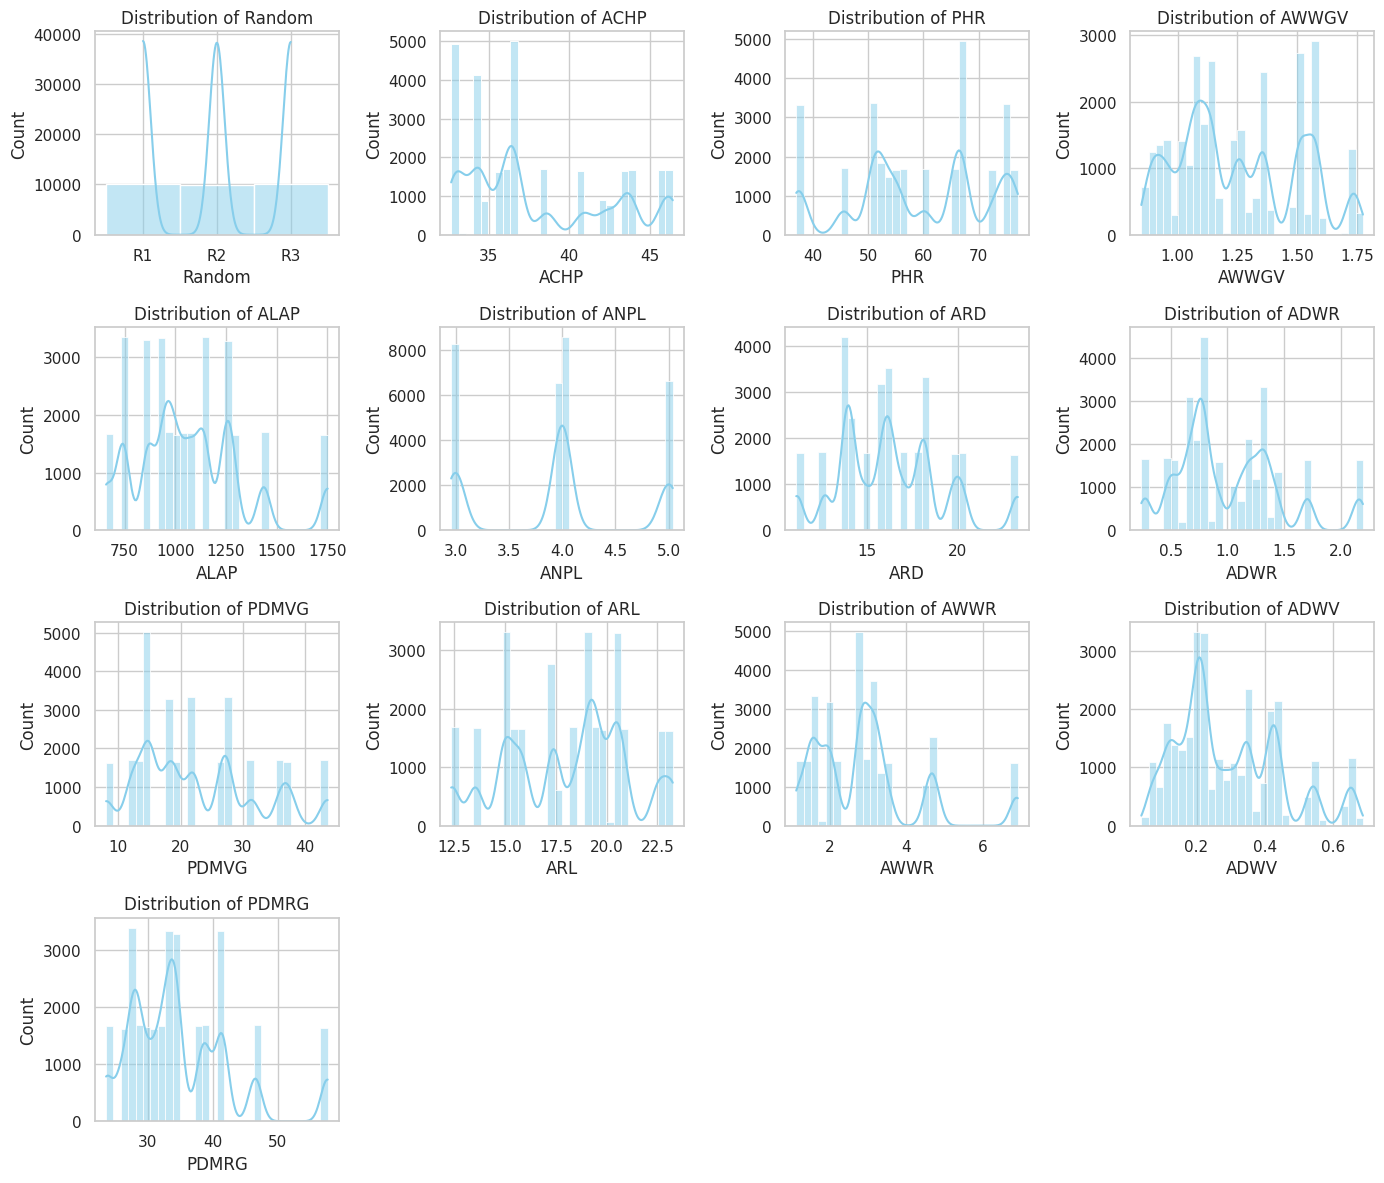

In [13]:
# 1. Distribution of Each Feature (Histogram)
features = ['Random', 'ACHP', 'PHR', 'AWWGV', 'ALAP', 'ANPL', 'ARD', 'ADWR', 
            'PDMVG', 'ARL', 'AWWR', 'ADWV', 'PDMRG']
plt.figure(figsize=(14, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[feature], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()
plt.show()


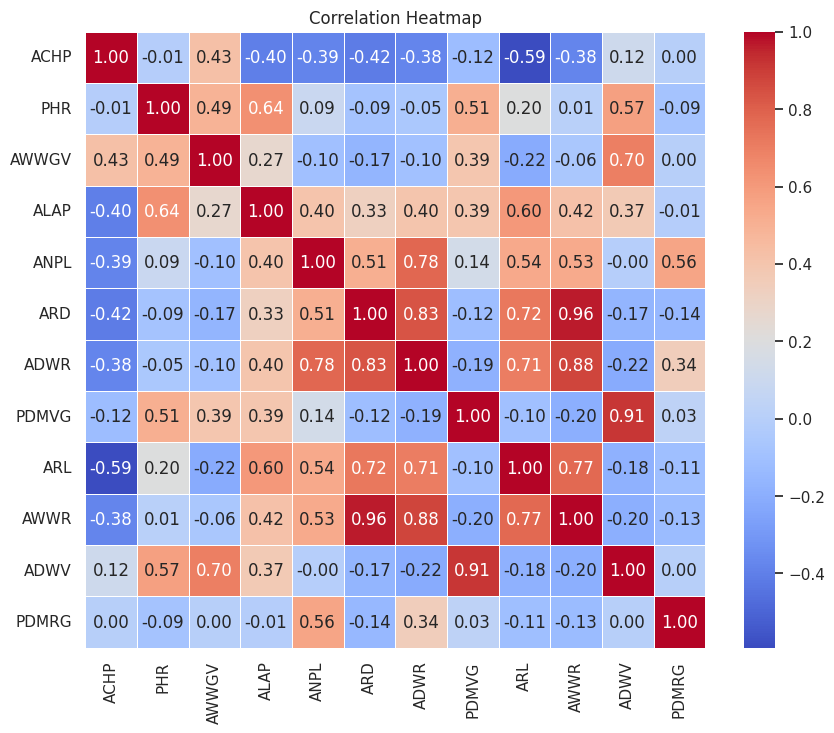

In [14]:
# 2. Correlation Heatmap (using only numeric columns)
plt.figure(figsize=(10, 8))
numeric_features = df[features].select_dtypes(include='number')
corr = numeric_features.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


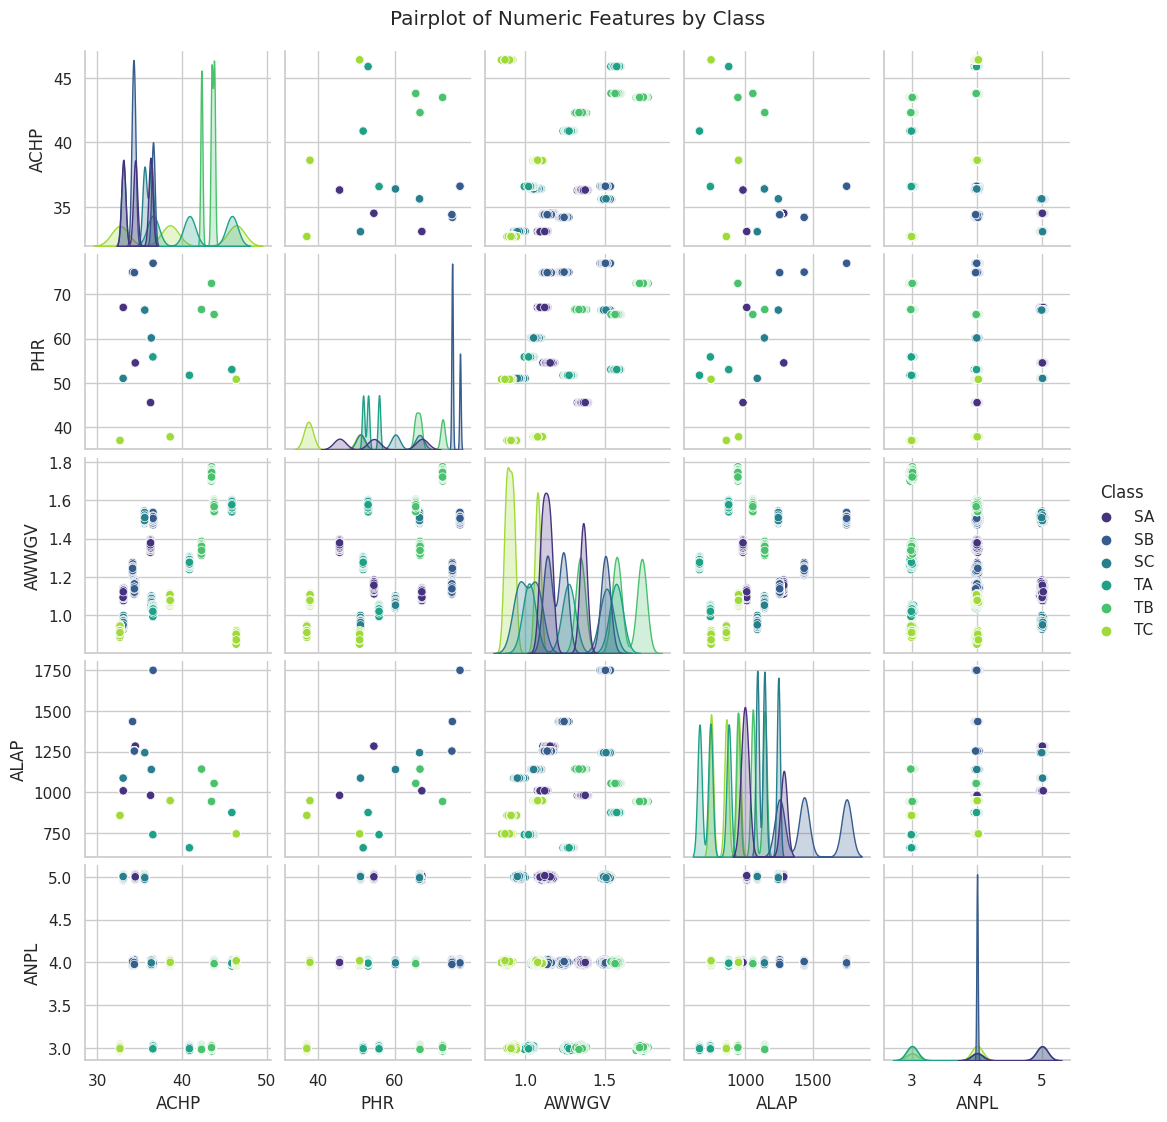

In [15]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if 'Class' in numeric_cols:
    numeric_cols.remove('Class')

# Step 2: Pairplot using first 5 numeric features
if 'Class' in df.columns and len(numeric_cols) > 0:
    sns.pairplot(df, vars=numeric_cols[:5], hue='Class', palette='viridis', height=2.2)
    plt.suptitle('Pairplot of Numeric Features by Class', y=1.02)
    plt.show()
else:
    print("Skipping pairplot: Either 'Class' column not found or no numeric features available.")

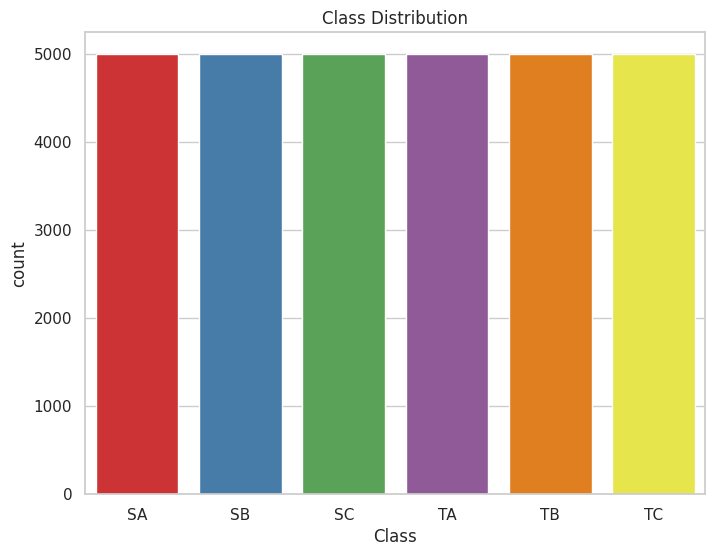

In [16]:
# 5. Class Distribution (Barplot)
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Class Distribution')
plt.show()


## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [18]:
# 1. Encode labels if 'Class' is not numeric
df = df.dropna(subset=['Class'])  # Remove missing labels
if df['Class'].dtype == 'object':
    le = LabelEncoder()
    df['Class'] = le.fit_transform(df['Class'])

# 2. Select numeric features only
features = df.select_dtypes(include='number').drop(columns=['Class']).columns.tolist()

X = df[features]
y = df['Class']

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Logistic Regression Accuracy: 100.00%


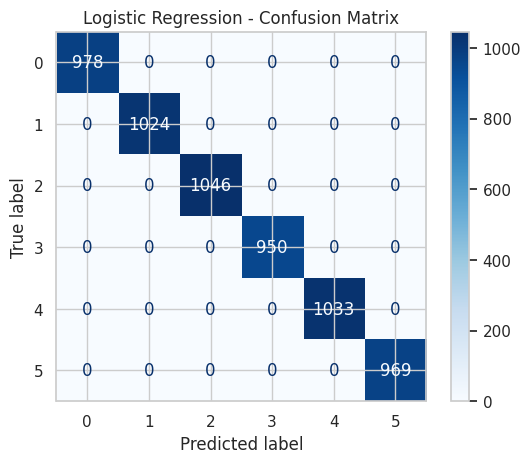


Decision Tree Accuracy: 100.00%


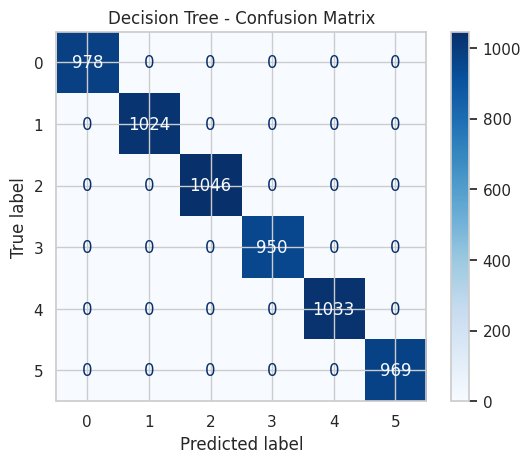


Random Forest Accuracy: 100.00%


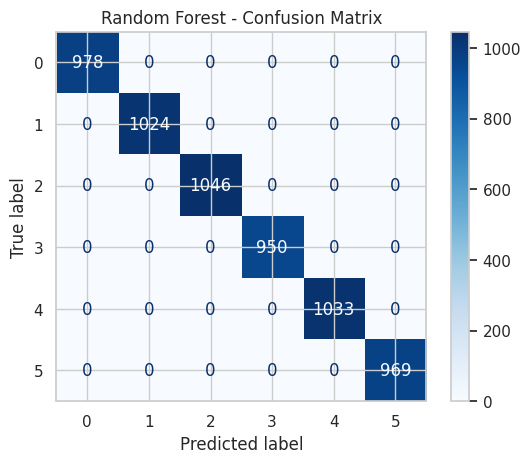


Support Vector Machine Accuracy: 83.57%


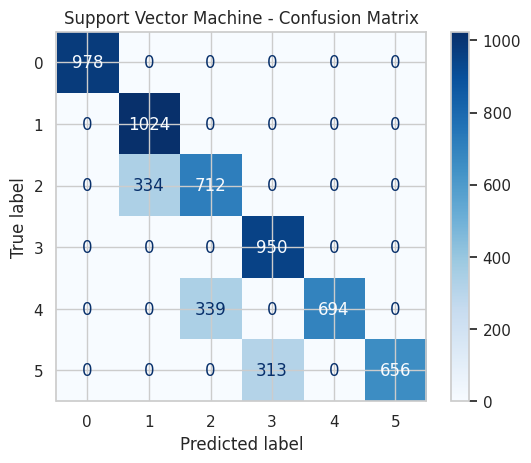


Naive Bayes Accuracy: 100.00%


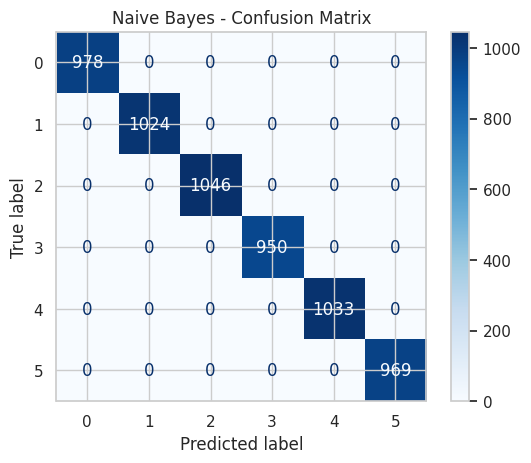


K-Nearest Neighbors Accuracy: 100.00%


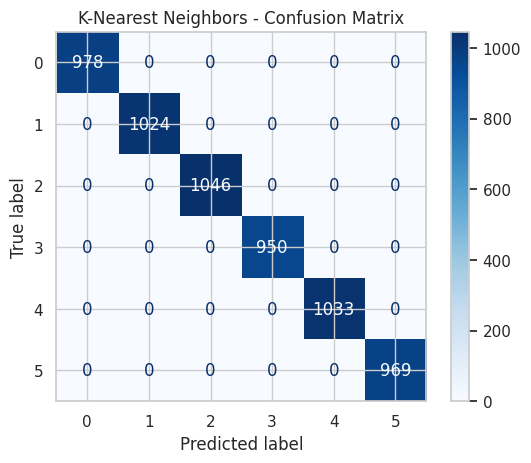

In [19]:
# 4. Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# 5. Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"\n{name} Accuracy: {acc:.2f}%")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

## Thank you..pls upvote!!!!